In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

--- Kernel Performance Comparison ---
Linear Kernel Test Accuracy: 46.67%
RBF Kernel Test Accuracy:    98.33%



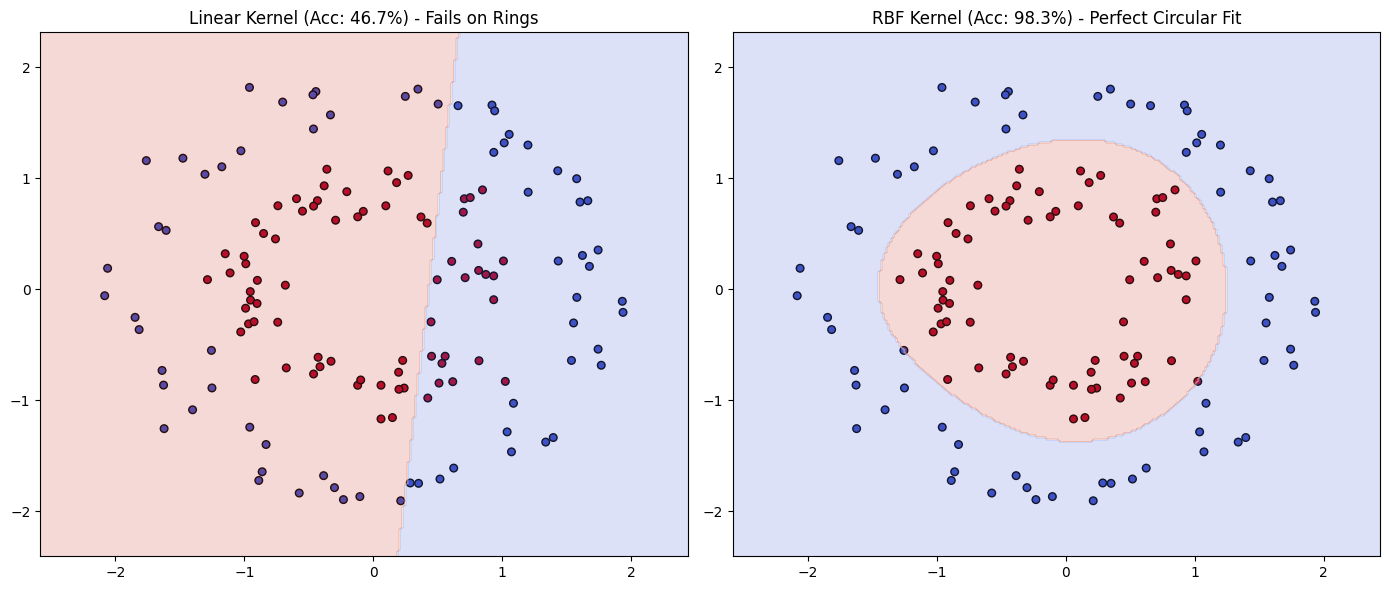

In [2]:
# Topic 117 | SVM - The Kernel Trick Explained
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# 1. Ek circular, non-linear dataset generate karein
# Isme ek class ke circles dusri class ke andar trapped hote hain
X, y = make_circles(n_samples=200, factor=0.5, noise=0.1, random_state=42)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Scaling (SVM ke liye zaroori hai)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------------
# MODEL 1: Linear Kernel (Linear Boundary)
# ------------------------------------------------------------------
linear_svc = SVC(kernel="linear", random_state=42)
linear_svc.fit(X_train_scaled, y_train)
linear_acc = linear_svc.score(X_test_scaled, y_test)

# ------------------------------------------------------------------
# MODEL 2: RBF Kernel (The Kernel Trick Approach)
# ------------------------------------------------------------------
rbf_svc = SVC(kernel="rbf", gamma="scale", random_state=42)
rbf_svc.fit(X_train_scaled, y_train)
rbf_acc = rbf_svc.score(X_test_scaled, y_test)

print("--- Kernel Performance Comparison ---")
print(f"Linear Kernel Test Accuracy: {linear_acc * 100:.2f}%")
print(f"RBF Kernel Test Accuracy:    {rbf_acc * 100:.2f}%\n")


# 2. Decision Boundaries Plot Karne Ka Function
def plot_boundaries(model, X, y, ax, title):
    ax.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap="coolwarm", edgecolors="k")

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.2, cmap="coolwarm")
    ax.set_title(title)


# Plot comparison side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_boundaries(
    linear_svc,
    X_train_scaled,
    y_train,
    axes[0],
    f"Linear Kernel (Acc: {linear_acc*100:.1f}%) - Fails on Rings",
)
plot_boundaries(
    rbf_svc,
    X_train_scaled,
    y_train,
    axes[1],
    f"RBF Kernel (Acc: {rbf_acc*100:.1f}%) - Perfect Circular Fit",
)

plt.tight_layout()
plt.show()

=== HIGH-DIMENSIONAL SVM RESULTS ===
Features ki tadad: 2000
Samples ki tadad:  200
Training Accuracy: 100.00%
Testing Accuracy:  56.67%
Total Support Vectors used: 140

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.43      0.50        30
           1       0.55      0.70      0.62        30

    accuracy                           0.57        60
   macro avg       0.57      0.57      0.56        60
weighted avg       0.57      0.57      0.56        60



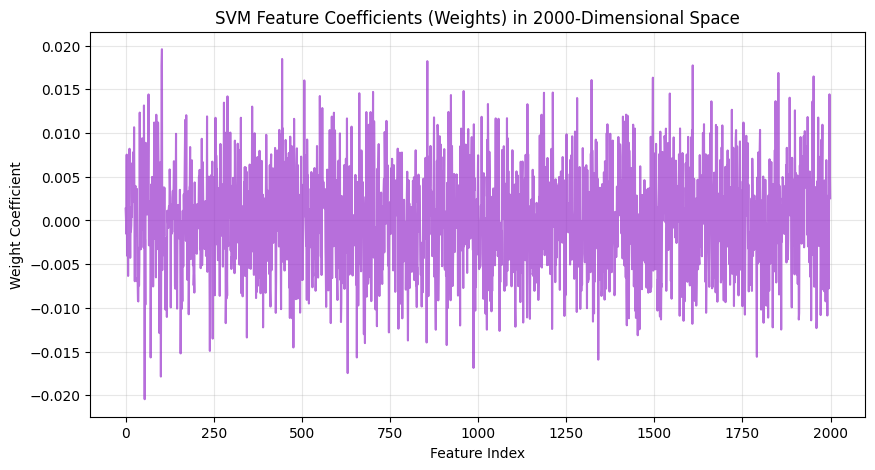

In [3]:
# Topic 118 | SVM - Handling High-Dimensional Data
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# 1. High-Dimensional Dataset generate karein
# Samples sirf 200 hain lekin Features 2000 hain! (n_features >> n_samples)
X, y = make_classification(
    n_samples=200,
    n_features=2000,
    n_informative=20,  # Sirf 20 features kaam ke hain, baki sab noise hai
    n_classes=2,
    random_state=42,
)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scaling: High dimensions mein scaling aur bhi zaroori ho jati hai
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Linear SVM Classifier use karein (High-dim ke liye standard)
# C ko thoda chota rakha hai taake noise control mein rahe (Regularization)
svm_high_dim = SVC(kernel="linear", C=0.1, random_state=42)
svm_high_dim.fit(X_train_scaled, y_train)

# 3. Model Evaluation
train_acc = svm_high_dim.score(X_train_scaled, y_train)
test_acc = svm_high_dim.score(X_test_scaled, y_test)

print("=== HIGH-DIMENSIONAL SVM RESULTS ===")
print(f"Features ki tadad: {X.shape[1]}")
print(f"Samples ki tadad:  {X.shape[0]}")
print(f"Training Accuracy: {train_acc * 100:.2f}%")
print(f"Testing Accuracy:  {test_acc * 100:.2f}%")
print(f"Total Support Vectors used: {svm_high_dim.support_vectors_.shape[0]}\n")

# 4. Predictions aur Detailed Report
y_pred = svm_high_dim.predict(X_test_scaled)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 5. Coefficients (Weights) ki Distribution Plot karein
# Yeh dikhayega ki SVM ne kis tarah fuzool features ke weights ko daba diya hai
coefs = svm_high_dim.coef_.flatten()

plt.figure(figsize=(10, 5))
plt.plot(coefs, color="darkorchid", alpha=0.7)
plt.title("SVM Feature Coefficients (Weights) in 2000-Dimensional Space")
plt.xlabel("Feature Index")
plt.ylabel("Weight Coefficient")
plt.grid(True, alpha=0.3)
plt.show()

Optimizing SVM Pipeline... (Best combinations dhoondi ja rahi hain)

--- Grid Search Results ---
Best Parameters Found: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Best CV Training Accuracy: 98.33%

--- Final Evaluation on Test Data ---
Test Set Accuracy: 96.67%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



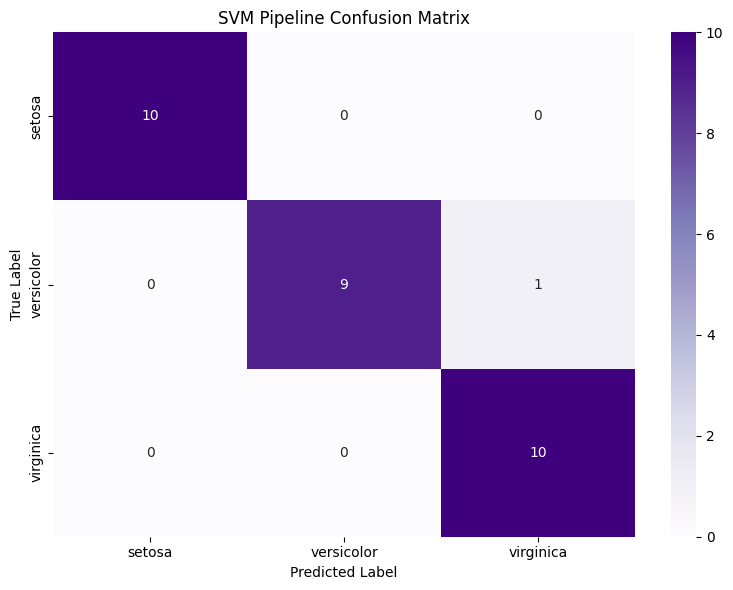

In [4]:
# Topic 119 | SVM - Implementation with Scikit-Learn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# 1. Dataset load karein (Iris Dataset - 3 Classes)
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names

# 2. Train-Test Split (80% Train, 20% Test)
# stratify=y classes ki percentage ko dono sets mein barabar rakhta hai
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. FEATURE SCALING (SVM ka sab se critical step)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Hyperparameter Grid Define Karein
# Hum linear aur rbf kernels ke sath different C aur gamma values test karenge
param_grid = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto", 0.01, 0.1, 1],
}

# 5. GridSearchCV Setup aur Training
# cv=5 yani 5-Fold Cross Validation use ho rahi hai
base_svc = SVC(random_state=42)
grid_search = GridSearchCV(
    estimator=base_svc, param_grid=param_grid, cv=5, scoring="accuracy", n_jobs=-1
)

print("Optimizing SVM Pipeline... (Best combinations dhoondi ja rahi hain)")
grid_search.fit(X_train_scaled, y_train)

# Best configuration print karein
print("\n--- Grid Search Results ---")
print(f"Best Parameters Found: {grid_search.best_params_}")
print(f"Best CV Training Accuracy: {grid_search.best_score_ * 100:.2f}%\n")

# 6. Best Model select karein aur predictions nikalyein
best_svm_model = grid_search.best_estimator_
y_pred = best_svm_model.predict(X_test_scaled)

# 7. Model Metrics Evaluation
test_accuracy = best_svm_model.score(X_test_scaled, y_test)
print("--- Final Evaluation on Test Data ---")
print(f"Test Set Accuracy: {test_accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# 8. Visualization: Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title("SVM Pipeline Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

=== k-NN CLASSIFIER RESULTS ===
Test Set Accuracy (k=5): 90.00%



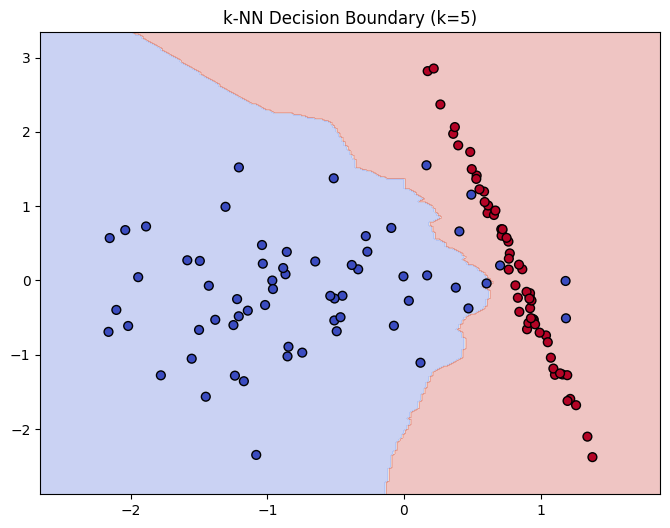

In [5]:
# Topic 120 | Introduction to k-Nearest Neighbors (k-NN)
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# 1. Dataset generate karein (2 Features taake plot karna aasan ho)
X, y = make_classification(
    n_samples=150,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42,
)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# CRITICAL STEP FOR k-NN: Feature Scaling
# Kyunki k-NN purely distance par chalta hai, features ka scale hona LAZMI hai
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. k-NN Classifier initialize aur train karein
# Hum k=5 neighbors check karenge aur euclidean distance use karenge
knn_model = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
knn_model.fit(X_train_scaled, y_train)

# 3. Model Evaluation
test_accuracy = knn_model.score(X_test_scaled, y_test)
print("=== k-NN CLASSIFIER RESULTS ===")
print(f"Test Set Accuracy (k=5): {test_accuracy * 100:.2f}%\n")


# 4. Decision Boundary Visualization
def plot_knn_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k", s=40)
    ax.set_title(title)


fig, ax = plt.subplots(figsize=(8, 6))
plot_knn_boundary(knn_model, X_train_scaled, y_train, ax, "k-NN Decision Boundary (k=5)")
plt.show()

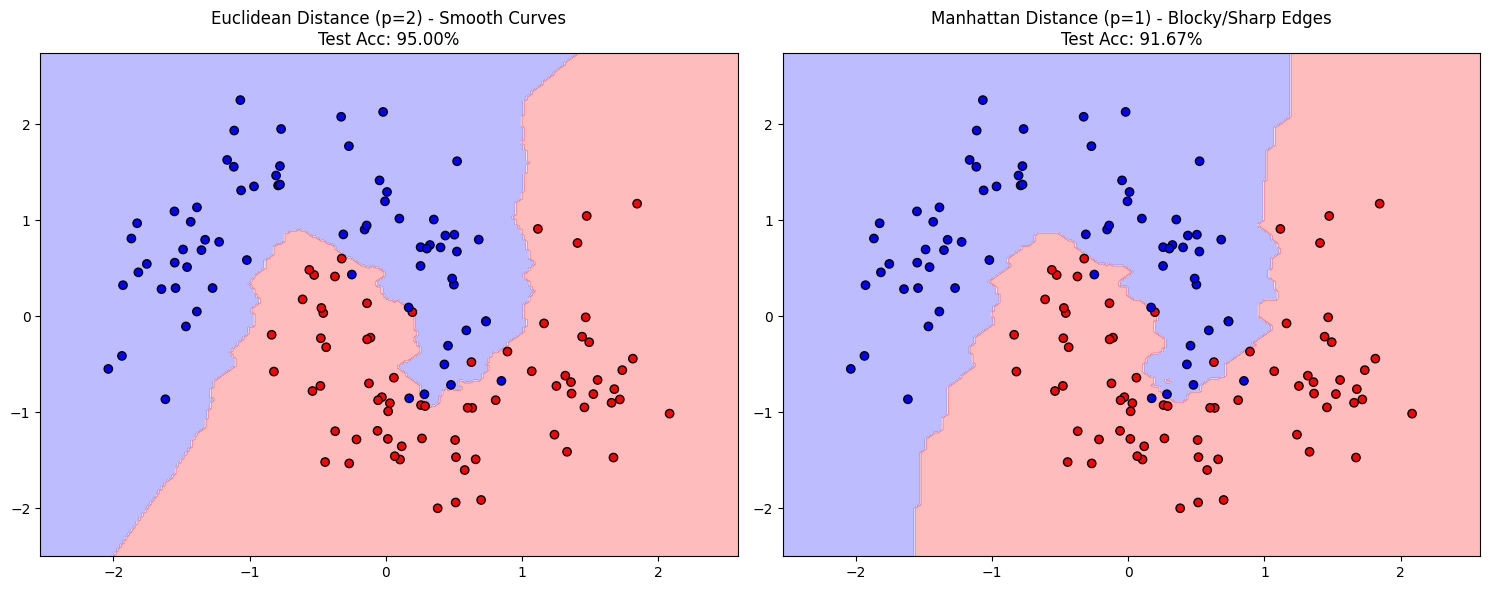

In [6]:
# Topic 121 | k-NN - Distance Metrics
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# 1. Complex Non-linear dataset generate karein (Moons dataset)
X, y = make_moons(n_samples=200, noise=0.25, random_state=42)

# Train-Test Split aur Scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Decision Boundary plot karne ka function
def plot_metrics_comparison(metric_name, p_val, ax, title):
    # k-NN model train karein makhsoos metric ke sath
    knn = KNeighborsClassifier(n_neighbors=5, metric=metric_name, p=p_val)
    knn.fit(X_train_scaled, y_train)

    # Accuracy check karein
    acc = knn.score(X_test_scaled, y_test)

    # Grid generate karein contour lines ke liye
    x_min, x_max = X_train_scaled[:, 0].min() - 0.5, X_train_scaled[:, 0].max() + 0.5
    y_min, y_max = X_train_scaled[:, 1].min() - 0.5, X_train_scaled[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02)
    )

    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot contours aur scatter points
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="bwr")
    ax.scatter(
        X_train_scaled[:, 0],
        X_train_scaled[:, 1],
        c=y_train,
        cmap="bwr",
        edgecolors="k",
    )
    ax.set_title(f"{title}\nTest Acc: {acc*100:.2f}%")


# Side-by-side comparison plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left Plot: Euclidean (L2 Norm)
plot_metrics_comparison(
    metric_name="euclidean",
    p_val=2,
    ax=axes[0],
    title="Euclidean Distance (p=2) - Smooth Curves",
)

# Right Plot: Manhattan (L1 Norm)
plot_metrics_comparison(
    metric_name="manhattan",
    p_val=1,
    ax=axes[1],
    title="Manhattan Distance (p=1) - Blocky/Sharp Edges",
)

plt.tight_layout()
plt.show()

In [7]:
# Topic 122 | k-NN - Performance Optimization Techniques
import time
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier

# 1. Ek bada aur dense dataset generate karein (20,000 samples)
X, y = make_classification(
    n_samples=20000, n_features=10, n_informative=8, random_state=42
)

# ------------------------------------------------------------------
# APPROACH 1: Brute-Force Search (Har point ko har ek se check karna)
# ------------------------------------------------------------------
knn_brute = KNeighborsClassifier(n_neighbors=5, algorithm="brute")
knn_brute.fit(X, y)

start_time = time.time()
# Data ke pehle 500 points par predictions check karte hain speed test ke liye
_ = knn_brute.predict(X[:500])
brute_time = time.time() - start_time

# ------------------------------------------------------------------
# APPROACH 2: Optimized KD-Tree Search
# ------------------------------------------------------------------
knn_kdtree = KNeighborsClassifier(n_neighbors=5, algorithm="kd_tree")
knn_kdtree.fit(X, y)

start_time = time.time()
_ = knn_kdtree.predict(X[:500])
kdtree_time = time.time() - start_time

# ------------------------------------------------------------------
# APPROACH 3: Optimized Ball-Tree Search
# ------------------------------------------------------------------
knn_ball = KNeighborsClassifier(n_neighbors=5, algorithm="ball_tree")
knn_ball.fit(X, y)

start_time = time.time()
_ = knn_ball.predict(X[:500])
ball_time = time.time() - start_time

# Results Print Karein
print("=== $k$-NN SEARCH OPTIMIZATION BENCHMARK ===")
print(f"Total Dataset Size: {X.shape[0]} rows")
print(f"Brute-Force Search Time: {brute_time:.4f} seconds")
print(f"KD-Tree Search Time:     {kdtree_time:.4f} seconds (Speedup!)")
print(f"Ball-Tree Search Time:   {ball_time:.4f} seconds (Speedup!)")

=== $k$-NN SEARCH OPTIMIZATION BENCHMARK ===
Total Dataset Size: 20000 rows
Brute-Force Search Time: 0.0731 seconds
KD-Tree Search Time:     0.0381 seconds (Speedup!)
Ball-Tree Search Time:   0.1254 seconds (Speedup!)


--- Elbow Method Analysis ---
Sab se kam error rate par Best $k$ value mili: 15

--- Final Model Performance ---
Test Set Accuracy with $k$=15: 100.00%

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       1.00      1.00      1.00        18
     class_2       1.00      1.00      1.00        12

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



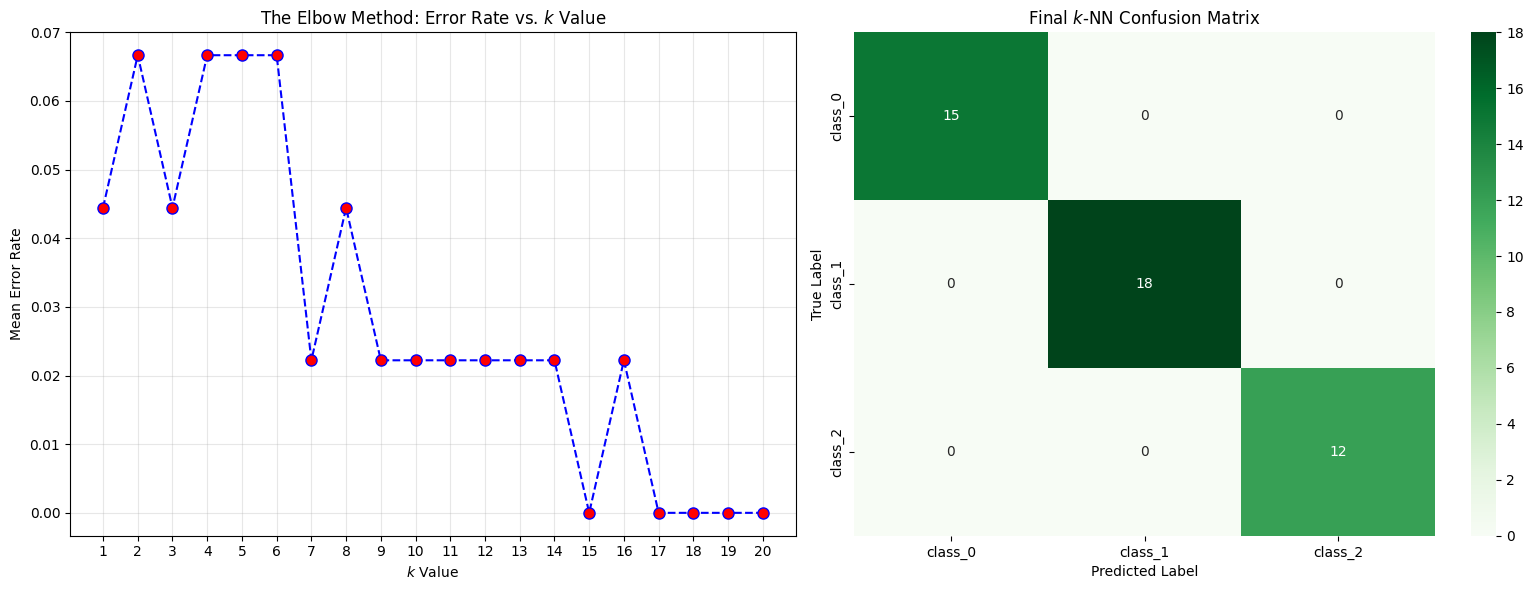

In [8]:
# Topic 123 | k-NN - Implementation with Scikit-Learn
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# 1. Dataset load karein (Wine Dataset - Multi-class task)
data = load_wine()
X, y = data.data, data.target
feature_names = data.feature_names
class_names = data.target_names

# 2. Train-Test Split (75% Train, 25% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 3. FEATURE SCALING (k-NN ka mandatory step)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------------
# STEP 4: The Elbow Method (Best k Value ki khoj)
# ------------------------------------------------------------------
error_rate = []

# 1 se 20 tak saare k values par check karte hain
for i in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=i, metric="euclidean")
    knn.fit(X_train_scaled, y_train)
    pred_i = knn.predict(X_test_scaled)
    # Jahan predictions match nahi kiye, unka mean nikal kar error rate save karte hain
    error_rate.append(np.mean(pred_i != y_test))

# Best k nikalne ke liye index dhoondte hain jahan error sab se kam ho
best_k = error_rate.index(min(error_rate)) + 1
print(f"--- Elbow Method Analysis ---")
print(f"Sab se kam error rate par Best $k$ value mili: {best_k}\n")

# ------------------------------------------------------------------
# STEP 5: Best k ke sath Final Model Train karein
# ------------------------------------------------------------------
# algorithm='auto' background mein khud optimize tree select kar leta hai
final_knn = KNeighborsClassifier(
    n_neighbors=best_k, metric="euclidean", algorithm="auto"
)
final_knn.fit(X_train_scaled, y_train)

# Predictions & Testing
y_pred = final_knn.predict(X_test_scaled)
test_accuracy = final_knn.score(X_test_scaled, y_test)

print(f"--- Final Model Performance ---")
print(f"Test Set Accuracy with $k$={best_k}: {test_accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# ------------------------------------------------------------------
# STEP 6: Visualizations (Elbow Plot & Confusion Matrix)
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Elbow Curve
axes[0].plot(
    range(1, 21),
    error_rate,
    color="blue",
    linestyle="dashed",
    marker="o",
    markerfacecolor="red",
    markersize=8,
)
axes[0].set_title("The Elbow Method: Error Rate vs. $k$ Value")
axes[0].set_xlabel("$k$ Value")
axes[0].set_ylabel("Mean Error Rate")
axes[0].set_xticks(range(1, 21))
axes[0].grid(True, alpha=0.3)

# Plot 2: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[1],
)
axes[1].set_title("Final $k$-NN Confusion Matrix")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

In [9]:
# Topic 124 | Introduction to Naive Bayes
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

# 1. Fake Email Dataset banayein (Text Data)
emails = [
    "Get free cash rewards now click here",
    "Hey friend are we meeting for football today",
    "Urgent money transfer offer expired soon",
    "Please review the attached project documentation",
    "Win a free lottery ticket cash prize inside",
    "Can you send me the lecture notes for tomorrow class",
]
# 1 = Spam, 0 = Ham (Not Spam)
labels = [1, 0, 1, 0, 1, 0]

# 2. Text Data ko Numbers (Vectors) mein convert karein
# CountVectorizer har lafadh ki tadad (frequency count) nikalta hai
vectorizer = CountVectorizer()
X_vectors = vectorizer.fit_transform(emails)

# Train-Test Split (Kyunki dataset chota hai, hum direct isi par test chala sakte hain)
X_train, X_test, y_train, y_test = train_test_split(
    X_vectors, labels, test_size=0.33, random_state=42
)

# 3. Multinomial Naive Bayes Classifier train karein
# MultinomialNB text counts ke liye sab se behtareen variant hai
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# 4. Model Evaluation
test_acc = nb_model.score(X_test, y_test)
print("=== NAIVE BAYES CLASSIFIER RESULTS ===")
print(f"Test Set Accuracy: {test_acc * 100:.2f}%\n")

# Naye unseen email par prediction test karein
new_email = ["Urgent free cash lottery inside"]
new_email_vector = vectorizer.transform(new_email)
prediction = nb_model.predict(new_email_vector)

print(f"New Email: '{new_email[0]}'")
print(f"Prediction: {'Spam' if prediction[0] == 1 else 'Ham (Not Spam)'}\n")

# 5. Confusion Matrix Table View
y_pred = nb_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

=== NAIVE BAYES CLASSIFIER RESULTS ===
Test Set Accuracy: 100.00%

New Email: 'Urgent free cash lottery inside'
Prediction: Spam

Confusion Matrix:
[[1 0]
 [0 1]]


In [10]:
# Topic 125 | Naive Bayes - Feature Independence Assumption
import numpy as np
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

# ------------------------------------------------------------------
# SCENARIO 1: Perfectly Independent Features (Ideal for Naive Bayes)
# ------------------------------------------------------------------
# n_repeated=0 aur n_redundant=0 ka matlab hai koi feature kisi dusre par depend nahi karta
X_ind, y_ind = make_classification(
    n_samples=500,
    n_features=5,
    n_informative=5,
    n_redundant=0,
    n_repeated=0,
    random_state=42,
)

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_ind, y_ind, test_size=0.3, random_state=42
)

model_independent = GaussianNB()
model_independent.fit(X_train_i, y_train_i)
acc_ind = accuracy_score(y_test_i, model_independent.predict(X_test_i))

# ------------------------------------------------------------------
# SCENARIO 2: Highly Dependent/Correlated Features (Violating Assumption)
# ------------------------------------------------------------------
# Hum deliberate redundancy aur repeated features add kar rahe hain
X_dep, y_dep = make_classification(
    n_samples=500,
    n_features=5,
    n_informative=2,
    n_redundant=3,  # 3 features informational features par dependent hain
    random_state=42,
)

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_dep, y_dep, test_size=0.3, random_state=42
)

model_dependent = GaussianNB()
model_dependent.fit(X_train_d, y_train_d)
acc_dep = accuracy_score(y_test_d, model_dependent.predict(X_test_d))

# Results print karein
print("=== NAIVE BAYES ASSUMPTION BENCHMARK ===")
print(f"Dataset 1 (Independent Features) Accuracy: {acc_ind * 100:.2f}%")
print(f"Dataset 2 (Highly Dependent Features) Accuracy:   {acc_dep * 100:.2f}%")

=== NAIVE BAYES ASSUMPTION BENCHMARK ===
Dataset 1 (Independent Features) Accuracy: 78.00%
Dataset 2 (Highly Dependent Features) Accuracy:   88.67%


In [11]:
# Topic 126 | Naive Bayes - Types of Models (Gaussian, Multinomial, Bernoulli)
import numpy as np
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

# ------------------------------------------------------------------
# 1. GAUSSIAN NB: Continuous Data Example
# ------------------------------------------------------------------
# Features: [Temperature in Celsius, Humidity Percentage]
X_continuous = np.array([[32.5, 80.2], [12.1, 40.5], [28.3, 75.0], [15.4, 35.2]])
y_continuous = np.array([1, 0, 1, 0])  # 1 = Play Tennis, 0 = Stay Inside

gaussian_model = GaussianNB()
gaussian_model.fit(X_continuous, y_continuous)
print("--- Gaussian NB Prediction ---")
print(f"Prediction for [30°C, 78%]: {gaussian_model.predict([[30.0, 78.0]])}\n")

# ------------------------------------------------------------------
# 2. MULTINOMIAL NB: Word Frequency/Count Data Example
# ------------------------------------------------------------------
# Features: [Count of word 'lottery', Count of word 'meeting']
X_counts = np.array([[4, 0], [0, 5], [3, 1], [0, 3]])
y_counts = np.array([1, 0, 1, 0])  # 1 = Spam, 0 = Ham

multinomial_model = MultinomialNB()
multinomial_model.fit(X_counts, y_counts)
print("--- Multinomial NB Prediction ---")
print(f"Prediction for email with 2 'lottery' words: {multinomial_model.predict([[2, 0]])}\n")

# ------------------------------------------------------------------
# 3. BERNOULLI NB: Binary Presence/Absence Data Example
# ------------------------------------------------------------------
# Features: [Is word 'cash' present?, Is word 'project' present?]
X_binary = np.array([[1, 0], [0, 1], [1, 1], [0, 1]])
y_binary = np.array([1, 0, 1, 0])  # 1 = Spam, 0 = Ham

bernoulli_model = BernoulliNB()
bernoulli_model.fit(X_binary, y_binary)
print("--- Bernoulli NB Prediction ---")
print(f"Prediction for email where 'cash' is present (1, 0): {bernoulli_model.predict([[1, 0]])}")

--- Gaussian NB Prediction ---
Prediction for [30°C, 78%]: [1]

--- Multinomial NB Prediction ---
Prediction for email with 2 'lottery' words: [1]

--- Bernoulli NB Prediction ---
Prediction for email where 'cash' is present (1, 0): [1]


In [12]:
# Topic 127 | Naive Bayes - Implementation with Scikit-Learn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
import warnings
warnings.filterwarnings('ignore')


# 1. Dataset Generation (Raw SMS text data strings)
sms_corpus = [
    "Hey, what's up? Are we still playing cricket tonight?",
    "URGENT! Your mobile number has won a £2,000 cash prize. Call 09061111 now!",
    "Can you please pick up some milk on your way home?",
    "FREE ringtone! Text replies to 80077 to claim your weekly bonus offer.",
    "Dear student, your DigiSkills course assignment deadline is tomorrow.",
    "WINNER!! As a valued customer you have been selected for a free holiday trip.",
    "Let me know when you are free so I can call you regarding the project.",
    "Get cheap insurance quotes today! Click this link now to save cash.",
]
# Labels: 0 = Ham (Normal SMS), 1 = Spam
labels = [0, 1, 0, 1, 0, 1, 0, 1]

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    sms_corpus, labels, test_size=0.25, random_state=42, stratify=labels
)

# 3. VECTORIZATION STEP: Convert Text to Numbers using TF-IDF
# stop_words='english' filters out common filler words like 'and', 'the', 'is'
tfidf_vectorizer = TfidfVectorizer(stop_words="english")

X_train_transformed = tfidf_vectorizer.fit_transform(X_train)
X_test_transformed = tfidf_vectorizer.transform(X_test)

# 4. Initialize and Train Multinomial Naive Bayes
# alpha=1.0 is Laplace Smoothing (prevents zero probability issue for new words)
nb_pipeline = MultinomialNB(alpha=1.0)
nb_pipeline.fit(X_train_transformed, y_train)

# 5. Model Evaluation
test_accuracy = nb_pipeline.score(X_test_transformed, y_test)
print("=== NAIVE BAYES TEXT PIPELINE RESULTS ===")
print(f"Test Set Prediction Accuracy: {test_accuracy * 100:.2f}%\n")

# 6. Test Data par Predictions aur Detailed Metrics Breakdown
y_pred = nb_pipeline.predict(X_test_transformed)
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Ham", "Spam"]))

# 7. Real-Time Inference (Test with completely unseen custom texts)
print("--- Real-Time Testing ---")
custom_messages = [
    "Are you free for a zoom meeting at 5pm?",
    "Claim your free bonus money right now by clicking here!",
]
custom_transformed = tfidf_vectorizer.transform(custom_messages)

# Yahan 'custom_predictions' (plural) kar diya hai taake loop se match kare
custom_predictions = nb_pipeline.predict(custom_transformed)

for msg, pred in zip(custom_messages, custom_predictions):
    label_text = "Spam" if pred == 1 else "Ham (Normal)"
    print(f"Message: '{msg}' -> Predicted Class: {label_text}")

=== NAIVE BAYES TEXT PIPELINE RESULTS ===
Test Set Prediction Accuracy: 50.00%

Detailed Classification Report:
              precision    recall  f1-score   support

         Ham       0.50      1.00      0.67         1
        Spam       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2

--- Real-Time Testing ---
Message: 'Are you free for a zoom meeting at 5pm?' -> Predicted Class: Ham (Normal)
Message: 'Claim your free bonus money right now by clicking here!' -> Predicted Class: Spam


In [13]:
# Topic 128 | Introduction to k-Means Clustering
